## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [33]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [36]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-May-2nd_filled.csv', encoding=enc)


In [37]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-05-16,2023,5,2023-05-15,39.662866,22.635299,0.240125,-0.026575,-0.239737,0.026575,0.378440,0.113461,-0.354095,-0.113461,0.096435,0.088987,0.075341,0.088987,2023-05-16,39.662866,22.635299,14659.0,13889.0,39.662866,22.635299,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,2023-05-16,39.650181,22.650104,91.643375,2023-05-09,2023-05-02,2023-05-09,2023-05-02,11.616080,20.296991
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-05-16,2023,5,2023-05-15,39.752697,22.707165,0.506922,0.087536,-0.458373,-0.087536,0.521654,0.109084,-0.459319,-0.109084,0.056933,0.073780,0.034842,0.073780,2023-05-16,39.752697,22.707165,14401.0,14149.0,39.752697,22.707165,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,2023-05-16,39.750182,22.750104,112.728533,2023-05-09,2023-05-02,2023-05-09,2023-05-02,16.491027,26.945055
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-05-16,2023,5,2023-05-15,39.788630,22.729622,0.412836,0.197057,-0.359560,-0.197057,0.507537,0.286973,-0.413971,-0.286973,0.100266,0.078218,0.067094,0.078218,2023-05-16,39.788630,22.729622,14593.0,14076.0,39.788630,22.729622,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,2023-05-16,39.750182,22.750104,112.728533,2023-05-09,2023-05-02,2023-05-09,2023-05-02,16.491027,26.945055
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-05-16,2023,5,2023-05-15,39.662866,22.779030,0.581554,0.279419,-0.469658,-0.279419,0.560371,0.306654,-0.461118,-0.306654,0.021617,0.019481,0.023684,0.019481,2023-05-16,39.662866,22.779030,14846.0,14261.0,39.662866,22.779030,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,2023-05-16,39.650181,22.750104,105.759527,2023-05-09,2023-05-02,2023-05-09,2023-05-02,13.129266,23.934843
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-05-16,2023,5,2023-05-15,39.698798,22.779030,0.555556,0.289508,-0.463127,-0.289508,0.567242,0.273051,-0.469870,-0.273051,0.023484,0.015142,0.020368,0.015142,2023-05-16,39.698798,22.779030,14884.0,14247.0,39.698798,22.779030,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,2023-05-16,39.750182,22.750104,112.728533,2023-05-09,2023-05-02,2023-05-09,2023-05-02,16.491027,26.945055


In [38]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [39]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [40]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [41]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-05-16,2023,5,0.240125,-0.026575,-0.239737,0.026575,0.378440,0.113461,-0.354095,-0.113461,0.096435,0.088987,0.075341,0.088987,14659.0,13889.0,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,91.643375,11.616080,20.296991
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-05-16,2023,5,0.506922,0.087536,-0.458373,-0.087536,0.521654,0.109084,-0.459319,-0.109084,0.056933,0.073780,0.034842,0.073780,14401.0,14149.0,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,112.728533,16.491027,26.945055
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-05-16,2023,5,0.412836,0.197057,-0.359560,-0.197057,0.507537,0.286973,-0.413971,-0.286973,0.100266,0.078218,0.067094,0.078218,14593.0,14076.0,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,112.728533,16.491027,26.945055
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-05-16,2023,5,0.581554,0.279419,-0.469658,-0.279419,0.560371,0.306654,-0.461118,-0.306654,0.021617,0.019481,0.023684,0.019481,14846.0,14261.0,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,105.759527,13.129266,23.934843
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-05-16,2023,5,0.555556,0.289508,-0.463127,-0.289508,0.567242,0.273051,-0.469870,-0.273051,0.023484,0.015142,0.020368,0.015142,14884.0,14247.0,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,112.728533,16.491027,26.945055


In [42]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-05-16,αγιας,θεσσαλιας,22.750267,39.710970,2023.0,5.0,0.531611,0.207713,-0.446233,-0.207713,0.570559,0.260947,-0.475327,-0.260947,0.050664,0.046043,0.038094,0.046043,14647.000000,14154.428571,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,108.076172,14.952625,26.845281
1,2023-05-16,αλμυρου,θεσσαλιας,22.692366,39.136391,2023.0,5.0,0.596137,0.279516,-0.486469,-0.279516,0.549603,0.243552,-0.450190,-0.243552,0.043370,0.039808,0.025882,0.039808,14656.222222,14151.000000,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,231.151969,11.012880,18.363057
2,2023-05-16,αλοννησου,θεσσαλιας,24.073790,39.328960,2023.0,5.0,0.493058,0.137236,-0.431136,-0.137236,0.499103,0.137082,-0.425521,-0.137082,0.036059,0.052143,0.019232,0.052143,14336.000000,14323.000000,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,202.539510,5.209890,28.413005
3,2023-05-16,αργιθεας,θεσσαλιας,21.430513,39.221380,2023.0,5.0,0.597637,0.302454,-0.493106,-0.302454,0.560003,0.257320,-0.465701,-0.257320,0.040313,0.053018,0.024440,0.053018,14357.000000,14048.666667,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,176.814853,1.147585,21.135921
4,2023-05-16,βολου,θεσσαλιας,22.883800,39.351977,2023.0,5.0,0.464503,0.129013,-0.400850,-0.129013,0.464067,0.139271,-0.398531,-0.139271,0.039976,0.042593,0.027566,0.042593,14771.000000,14080.666667,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,172.052106,10.429566,20.763135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-05-16,τεμπων,θεσσαλιας,22.553160,39.852112,2023.0,5.0,0.511804,0.199036,-0.425108,-0.199036,0.487281,0.195427,-0.402644,-0.195427,0.026293,0.042519,0.016377,0.042519,14620.400000,14193.600000,14131.844872,13769.820000,14115.170075,13710.264791,14425.669118,13892.648535,14496.147902,13987.089286,90.443463,6.463702,27.740014
21,2023-05-16,τρικκαιων,θεσσαλιας,21.797560,39.635058,2023.0,5.0,0.503202,0.197929,-0.443614,-0.197929,0.551718,0.234198,-0.473066,-0.234198,0.062168,0.069954,0.045223,0.069954,14775.800000,14268.200000,14191.183077,13785.802381,14353.424316,13765.126176,14621.389846,13986.928283,14689.561490,14047.238095,176.999873,13.713732,32.495788
22,2023-05-16,τυρναβου,θεσσαλιας,22.343000,39.828472,2023.0,5.0,0.598336,0.234130,-0.507208,-0.234130,0.481039,0.179341,-0.408239,-0.179341,0.027967,0.045633,0.018021,0.045633,14764.250000,14253.750000,14205.631944,13756.379121,14250.387054,13720.940664,14569.709428,13922.793269,14687.921314,14042.280258,67.877909,5.999722,12.930523
23,2023-05-16,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2023.0,5.0,0.462285,0.109702,-0.426134,-0.109702,0.478616,0.147639,-0.435837,-0.147639,0.061883,0.067354,0.036424,0.067354,14730.000000,14242.000000,14179.025000,13814.481685,14325.770833,13813.812500,14609.167725,14019.155400,14719.909041,14095.839286,137.263723,17.629915,34.227020


In [43]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [44]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [45]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [46]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [47]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [48]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'THESSALY'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [49]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [50]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

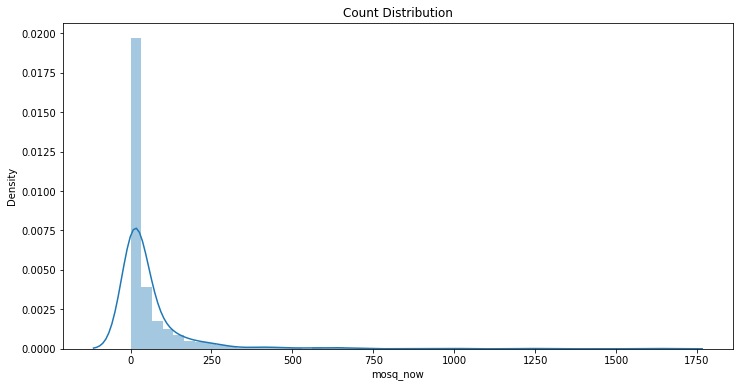

In [51]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [52]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

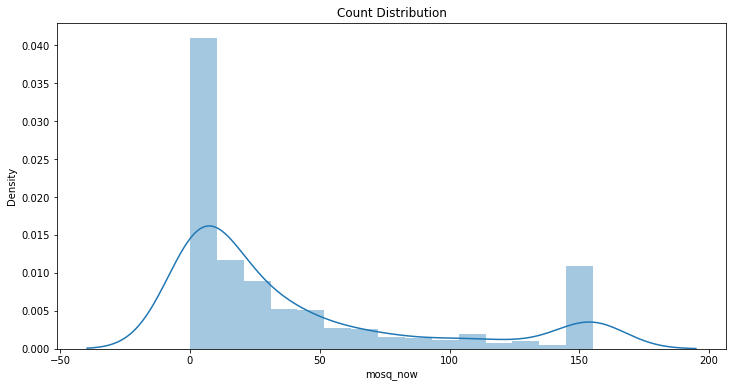

In [53]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

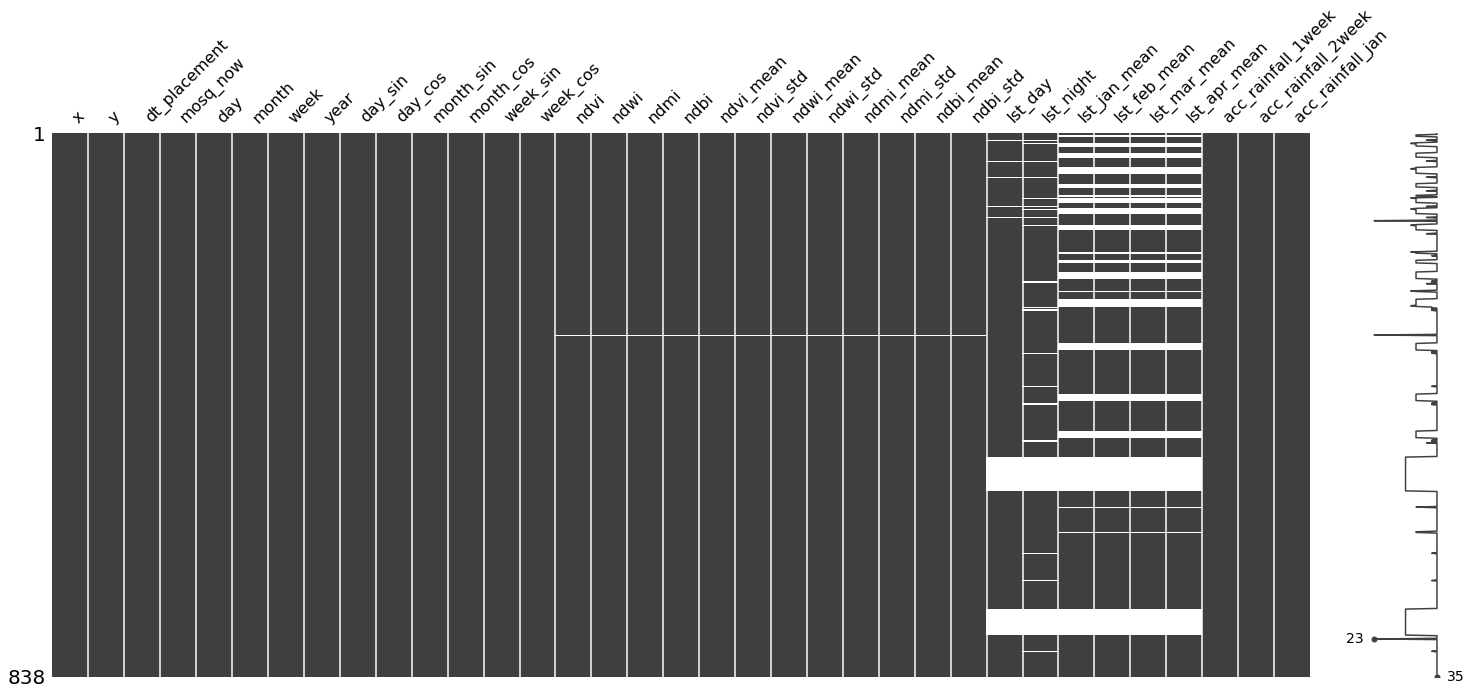

In [54]:
missingno.matrix(mosquito_data_nuts2)

In [55]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [56]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

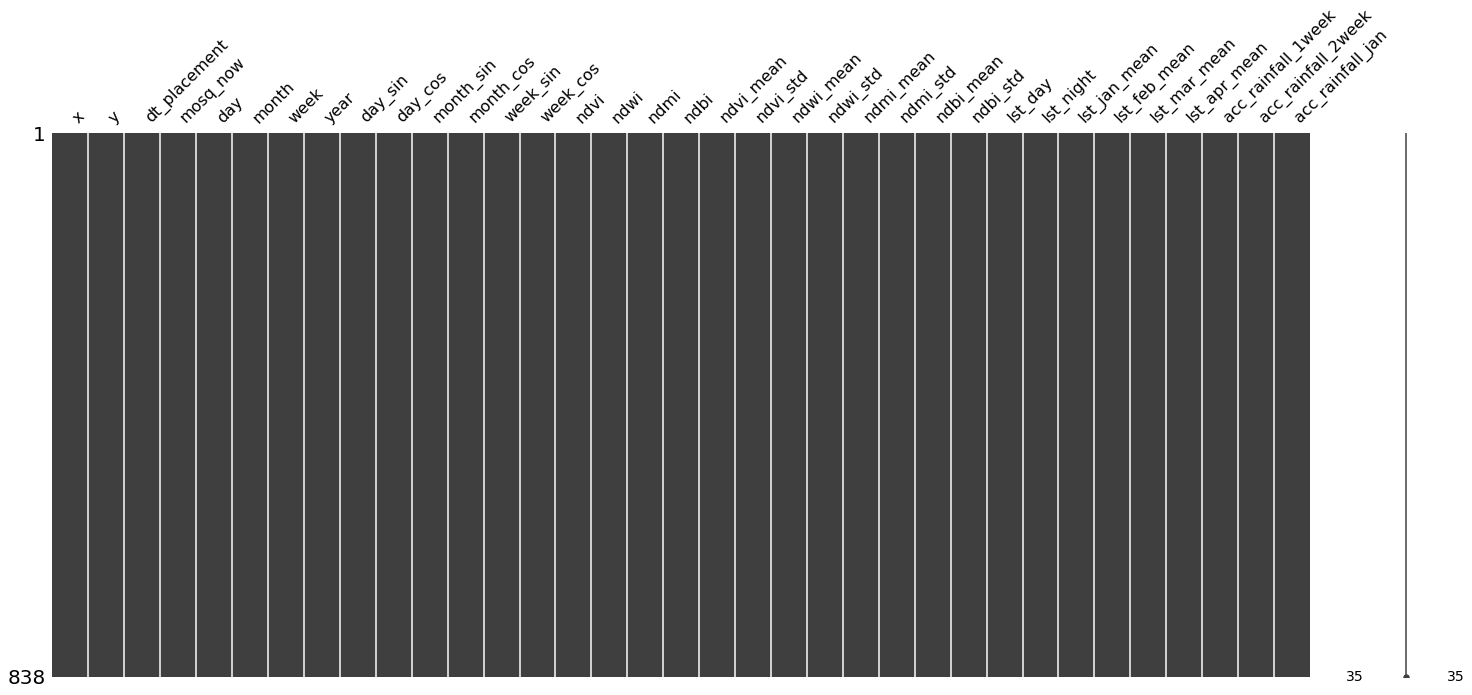

In [57]:
missingno.matrix(mosquito_data_nuts2)

In [58]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [59]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   16.5 155.3]


In [60]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 39.84802 | Val Loss: 25.66702 | Train Acc: 4.014| Val Acc: 2.827
Epoch 002: | Train Loss: 36.45695 | Val Loss: 25.56091 | Train Acc: 3.463| Val Acc: 2.833
Epoch 003: | Train Loss: 34.75945 | Val Loss: 26.85146 | Train Acc: 3.135| Val Acc: 2.972
Epoch 004: | Train Loss: 34.16678 | Val Loss: 25.49316 | Train Acc: 2.936| Val Acc: 2.622
Epoch 005: | Train Loss: 33.61902 | Val Loss: 23.47873 | Train Acc: 2.846| Val Acc: 2.156
Epoch 006: | Train Loss: 32.97711 | Val Loss: 23.30387 | Train Acc: 2.783| Val Acc: 2.083
Epoch 007: | Train Loss: 33.01652 | Val Loss: 24.57395 | Train Acc: 2.687| Val Acc: 2.429
Epoch 008: | Train Loss: 32.84860 | Val Loss: 24.49611 | Train Acc: 2.684| Val Acc: 2.408
Epoch 009: | Train Loss: 32.17328 | Val Loss: 23.22829 | Train Acc: 2.630| Val Acc: 2.045
Epoch 010: | Train Loss: 32.20259 | Val Loss: 22.84206 | Train Acc: 2.548| Val Acc: 1.830
Epoch 011: | Train Loss: 32.05634 | Val Loss: 22.82756 | Train Acc: 2.556| Val Acc: 1.836
Epoch 012:

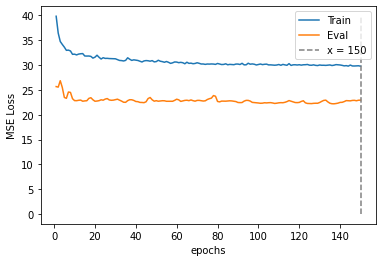

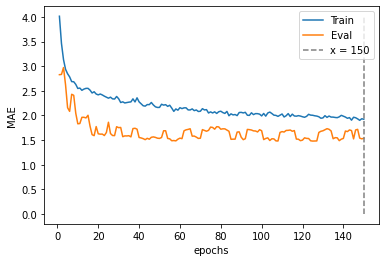

In [61]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [62]:
metrics(train, test, threshold=30)

MAE on train set:  22.53966946946441
min prediction: 1
max prediction: 205

MAE on test set:  25.997709899847337
Error ⩽ 30: 70.23 %
min prediction: 1
max prediction: 197


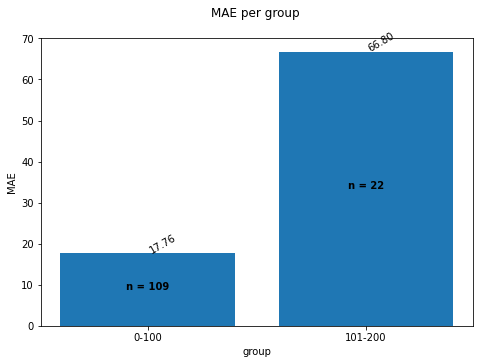

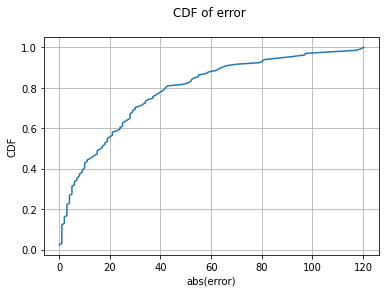

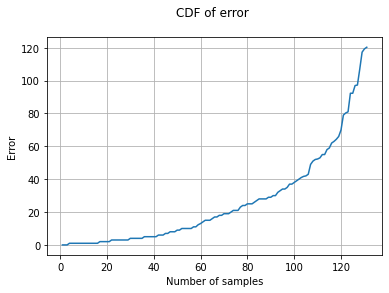

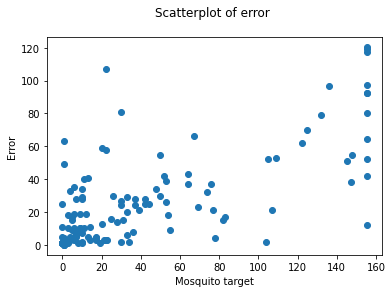

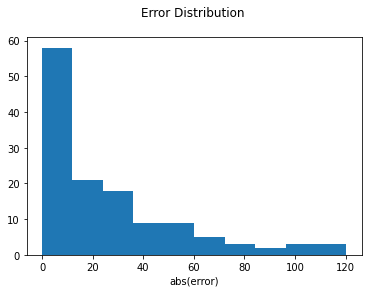

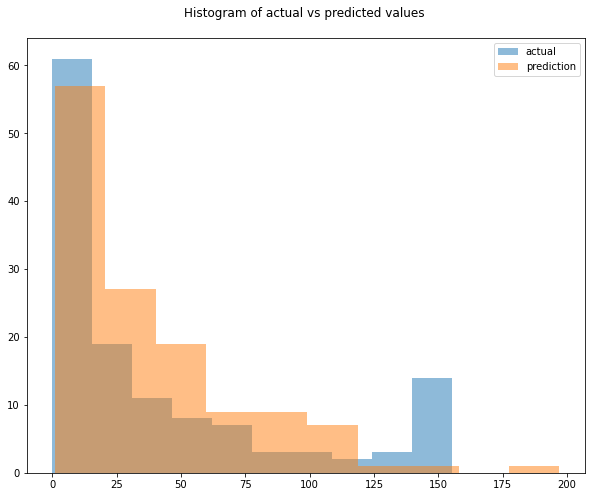

In [63]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 34.05254 | Val Loss: 0.00280 | Train Acc: 2.363| Val Acc: 0.045
Epoch 002: | Train Loss: 33.57188 | Val Loss: 0.11836 | Train Acc: 2.369| Val Acc: 0.045
Epoch 003: | Train Loss: 33.63815 | Val Loss: 0.15623 | Train Acc: 2.321| Val Acc: 0.045
Epoch 004: | Train Loss: 33.18555 | Val Loss: 0.05998 | Train Acc: 2.265| Val Acc: 0.045
Epoch 005: | Train Loss: 32.77693 | Val Loss: 0.00060 | Train Acc: 2.208| Val Acc: 0.045
Epoch 006: | Train Loss: 32.89710 | Val Loss: 0.02806 | Train Acc: 2.200| Val Acc: 0.045
Epoch 007: | Train Loss: 32.64202 | Val Loss: 0.00093 | Train Acc: 2.255| Val Acc: 0.045
Epoch 008: | Train Loss: 32.86219 | Val Loss: 0.07521 | Train Acc: 2.213| Val Acc: 0.045
Epoch 009: | Train Loss: 32.51617 | Val Loss: 0.25737 | Train Acc: 2.191| Val Acc: 0.045
Epoch 010: | Train Loss: 32.52486 | Val Loss: 0.11834 | Train Acc: 2.200| Val Acc: 0.045
Epoch 011: | Train Loss: 32.33071 | Val Loss: 0.00366 | Train Acc: 2.153| Val Acc: 0.045
Epoch 012: | Train Lo

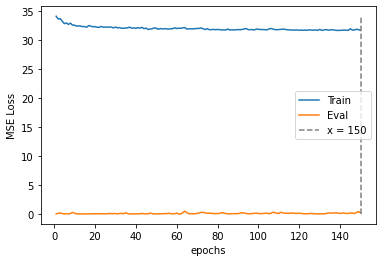

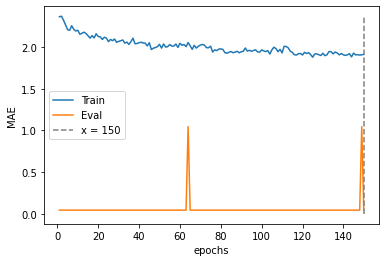

In [64]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [65]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [66]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [67]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [68]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [69]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [70]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

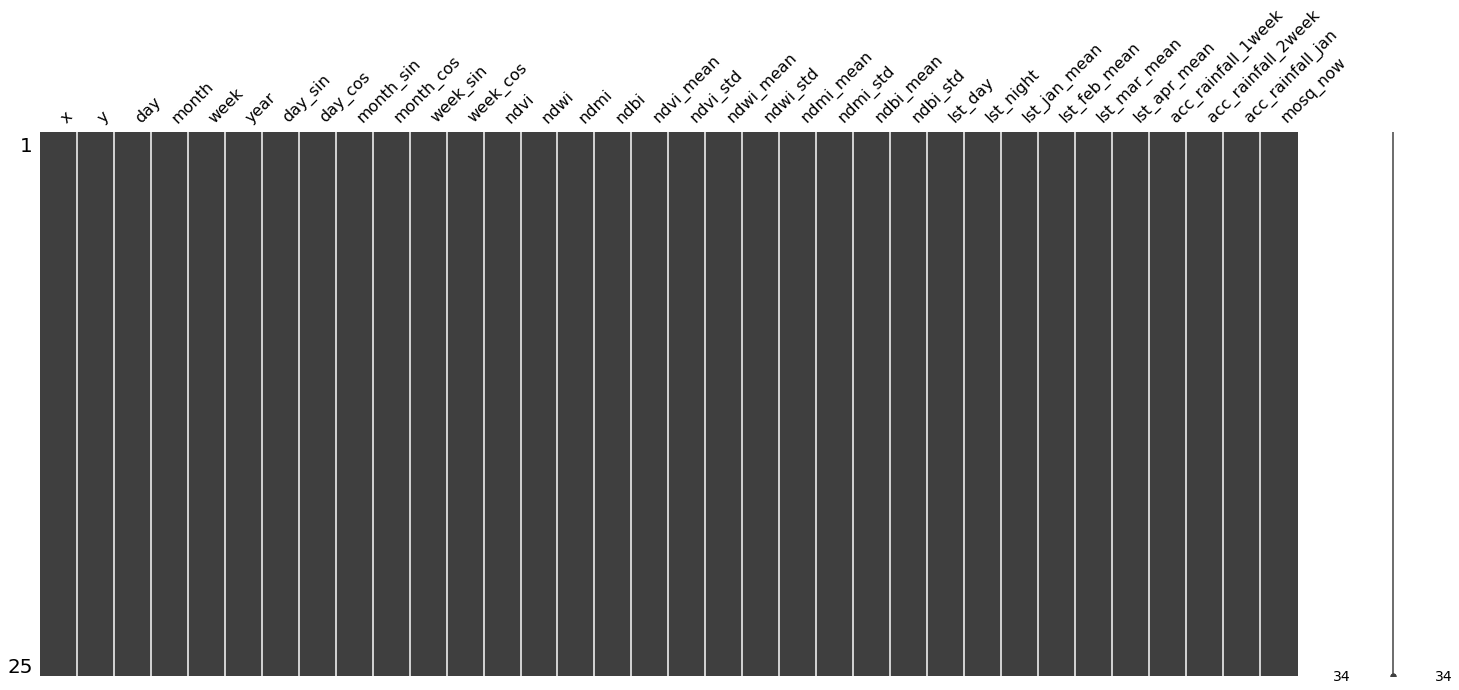

In [71]:
missingno.matrix(dataset_mamoth)

In [72]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [73]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [74]:
predictions = give_predictions(model, dataset_mamoth)

In [75]:
mosqutio_predictions['mosq_pred'] = predictions

In [76]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2023-05-16,18
1,22.692366,39.136391,2023-05-16,17
2,24.073790,39.328960,2023-05-16,1
3,21.430513,39.221380,2023-05-16,13
4,22.883800,39.351977,2023-05-16,23
...,...,...,...,...
20,22.553160,39.852112,2023-05-16,21
21,21.797560,39.635058,2023-05-16,23
22,22.343000,39.828472,2023-05-16,29
23,22.020557,39.603750,2023-05-16,38


In [77]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-May-2nd.csv', index = False)